#### Functions

In [ ]:
import numpy as np
import tensorflow as tf

# Loader parameters
batch_size = 16
img_height = 256
img_width = 256

# Load Data function, set the path to dataset
def load_data(path, batch_size, img_height, img_width):
    return tf.keras.utils.image_dataset_from_directory(
        path,
        seed=4266,
        image_size=(img_height, img_width),
        batch_size=batch_size)

# This function randomly applies flips, gaussian blur and black box erasing with a probability of 0.4 which is the factor to each image
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomFlip('vertical'),
    tf.keras.layers.RandomGaussianBlur(kernel_size=(5,5), 
                                       sigma=(0.3, 3.0)), 
    tf.keras.layers.RandomErasing(factor=0.4, #edit this for probability
                                  fill_value=0),
  ])

# Applies data_augmentation layer to 1 image
def get_augmented_image(image, label): # upper bound of percentage, so if we set 0.3 then 30% of the images will be augmented
  image = data_augmentation(image, training=True)
  return image, label

# Shuffles the dataset, gets an % of dataset and applies augmentation to it
def get_augmented_ds(ds, percentage):
  ds = ds.shuffle(buffer_size=100,seed=4266, reshuffle_each_iteration=True)
  ds =  ds.take(np.floor(percentage * len(ds)))
  return ds.map(get_augmented_image)

# Reshuffles the dataset again using resampling so mixed dataset.
def get_new_ds(ds, percentage): #Percentage is the amount of train data to augment
  ds_augmented = get_augmented_ds(ds, percentage) #percentage here to edit
  ds_shuffle = tf.data.Dataset.sample_from_datasets([ds_augmented, ds], weights = [percentage, 1], seed=4266)
  return ds_shuffle

#### How To Use

In [ ]:
import os
os.getcwd() # get cwd

'c:\\Users\\shiro\\OneDrive\\Desktop\\dsa4266\\DSA4266\\scripts'

In [52]:
#Loading Train Dataset
path = '../data/deepdetect-2025_dddata/ddata/train'
ds = load_data(path, batch_size, img_height, img_width)

Found 90409 files belonging to 2 classes.


In [27]:
ds_new = get_new_ds(ds, 0.3)

In [34]:
tf.data.experimental.cardinality(ds_new).numpy()

np.int64(-2)

In [11]:
import matplotlib.pyplot as plt

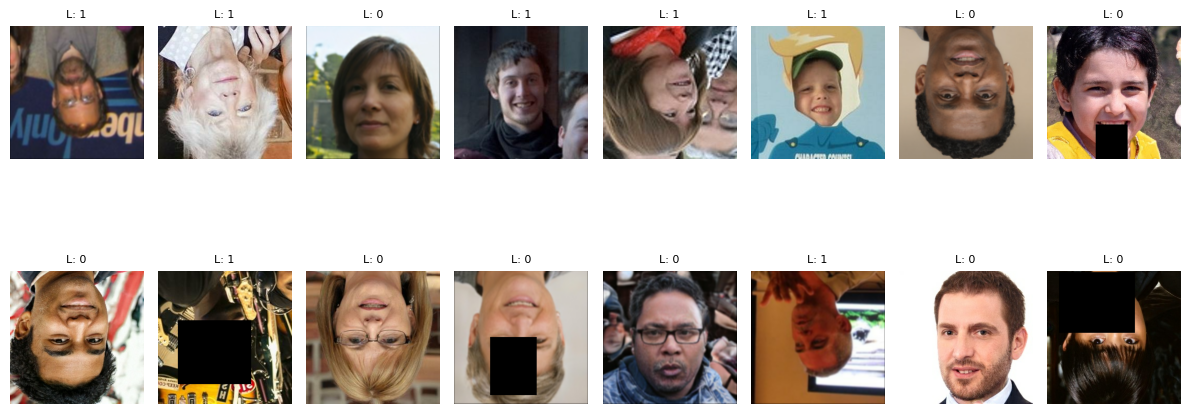

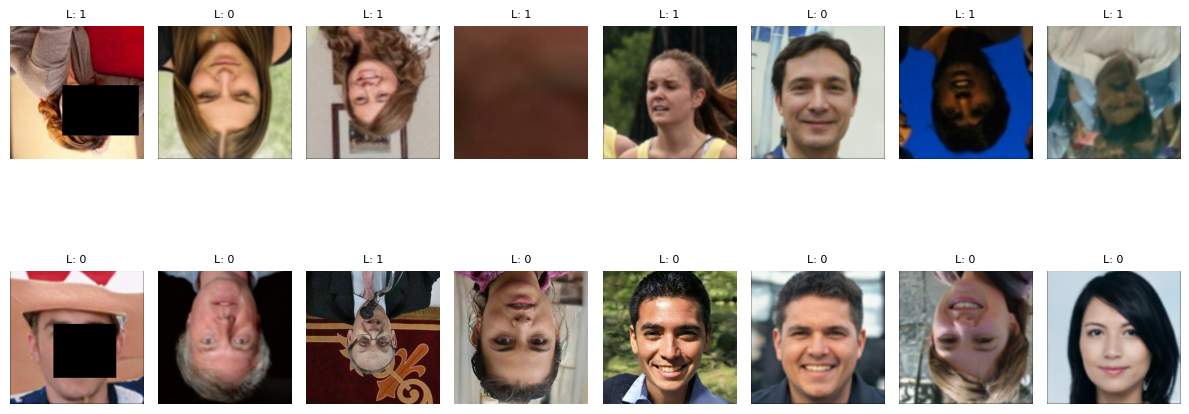

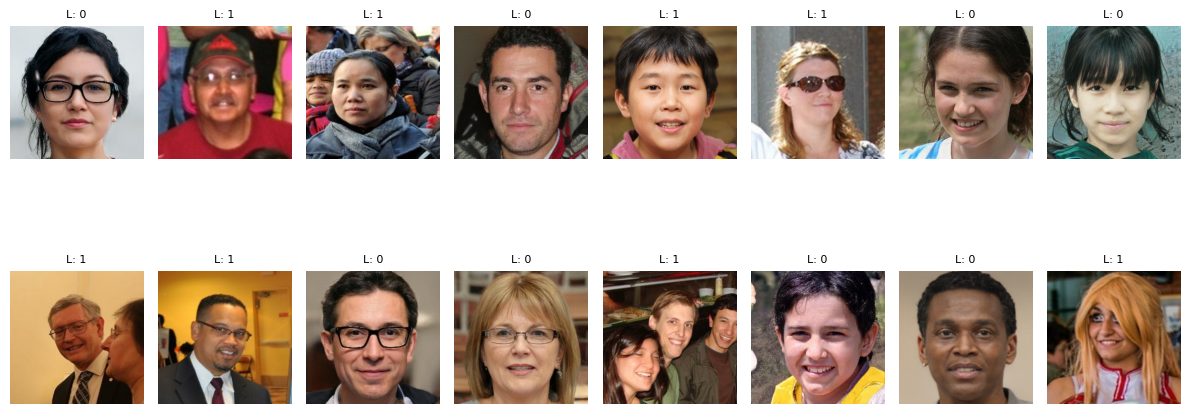

In [43]:

# ds_new.take(1) gets exactly one batch of 16 images
for images, labels in ds_new.take(3): 
    plt.figure(figsize=(12, 6))
    
    batch_actual_size = images.shape[0] # This will be 16
    
    for i in range(batch_actual_size):
        # Create a 2x8 grid for 16 images
        plt.subplot(2, 8, i + 1) 
        
        # Optimization: convert to uint8 for display to save RAM
        # If your images are already 0-255, casting to uint8 is safer than float32/255
        display_image = images[i].numpy().astype("uint8")
        
        plt.imshow(display_image)
        plt.title(f"L: {labels[i].numpy()}", fontsize=8)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    plt.close()
